In [4]:
import pandas as pd

df = pd.read_csv("data/lectures evaluation.csv", header=None)
df.columns = ["c1", "c2", "c3", "c4", "target"]

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df["target"].value_counts().sort_index())

Shape: (1000, 5)

Class distribution:
target
0.0     93
1.0    280
2.0    403
3.0    197
4.0     27
Name: count, dtype: int64


## Class Merging

Original 5 classes (0–4) are imbalanced — class 0 has 93 and class 4 only 27 samples.
We merge the boundary classes: 0+1 → 0 (low), 2 → 1 (medium), 3+4 → 2 (high).
This gives 3 balanced classes with enough samples each to train and evaluate reliably.

In [5]:
target_map = {0.0: 0, 1.0: 0, 2.0: 1, 3.0: 2, 4.0: 2}
df["target"] = df["target"].map(target_map)
print(df["target"].value_counts().sort_index())

target
0    373
1    403
2    224
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X = df[["c1", "c2", "c3", "c4"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, stratify=y
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train: 800  Test: 200

Train class distribution:
target
0    298
1    323
2    179
Name: count, dtype: int64

Test class distribution:
target
0    75
1    80
2    45
Name: count, dtype: int64


## Model Training

We use XGBoost with `multi:softprob` objective for 3-class output.
`max_depth=3` keeps trees shallow and interpretable.
`monotone_constraints=(1,1,1,1)` enforces that all 4 criteria are gain-type
— higher value always pushes toward a higher class.
100 estimators balances accuracy and overfitting on 800 training samples.

In [9]:
import xgboost as xgb

CRITERIA_NR = 4
NUM_CLASSES = 3

model = xgb.XGBClassifier(
    max_depth=3,
    eta=0.1,
    n_estimators=100,
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    monotone_constraints="(1,1,1,1)",
    eval_metric="mlogloss",
    seed=1234,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Metrics

We report Accuracy, weighted F1, and AUC (one-vs-rest) on both train and test sets.
Weighted F1 accounts for class imbalance. AUC with `multi_class='ovr'` gives a
reliable measure of separability across all 3 classes.

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(model, X, y, split_name="Test"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average="weighted")
    auc = roc_auc_score(y, y_proba, multi_class="ovr", average="weighted")

    print(f"[{split_name}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}")

evaluate(model, X_train, y_train, "Train")
evaluate(model, X_test, y_test, "Test ")

[Train]  Accuracy: 0.7250  |  F1: 0.7260  |  AUC: 0.8729
[Test ]  Accuracy: 0.7250  |  F1: 0.7255  |  AUC: 0.8770


## Confusion Matrix

Shows where the model makes mistakes. We expect most errors on the boundary
between adjacent classes (0↔1, 1↔2) since the criteria values overlap there.

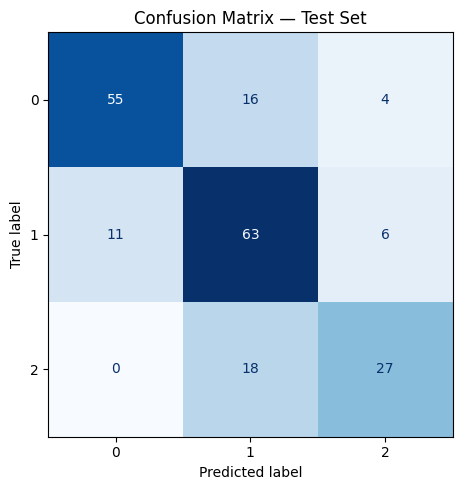

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

## Feature Importance

We use gain-based importance: average loss reduction from splits on each feature.
This is more meaningful than frequency-based (f-score) since it reflects
how much each criterion actually improves predictions.

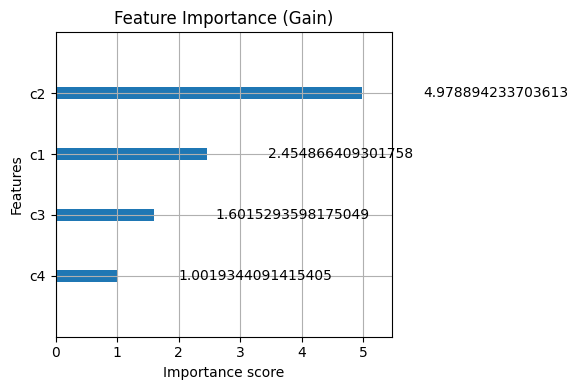

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
xgb.plot_importance(model, importance_type="gain", ax=ax)
ax.set_title("Feature Importance (Gain)")
plt.tight_layout()
plt.show()

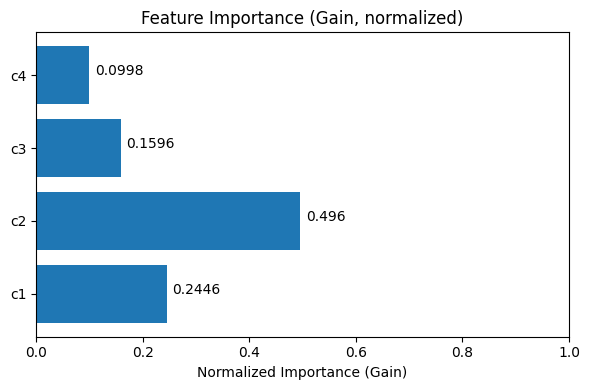

{'c1': 0.2446, 'c2': 0.496, 'c3': 0.1596, 'c4': 0.0998}


In [15]:
booster = model.get_booster()
scores = booster.get_score(importance_type="gain")

# Normalize to sum to 1
total = sum(scores.values())
normalized = {k: round(v / total, 4) for k, v in scores.items()}

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(normalized.keys()), list(normalized.values()))
ax.set_xlim(0, 1)
ax.set_xlabel("Normalized Importance (Gain)")
ax.set_title("Feature Importance (Gain, normalized)")
for i, (k, v) in enumerate(normalized.items()):
    ax.text(v + 0.01, i, str(v))
plt.tight_layout()
plt.show()

print(normalized)

## SHAP Values

SHAP (SHapley Additive exPlanations) explains each prediction by attributing
a contribution value to each criterion. TreeExplainer is exact for XGBoost —
not an approximation. We use a beeswarm plot for global interpretation across
all test samples.

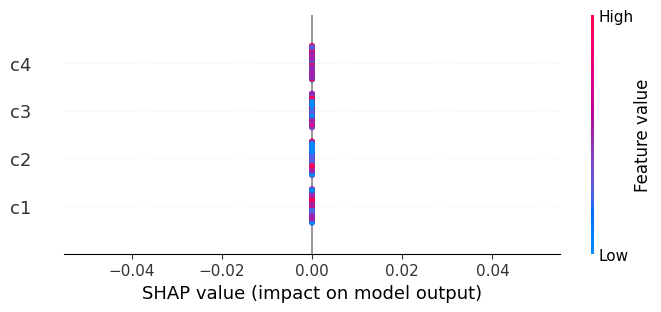

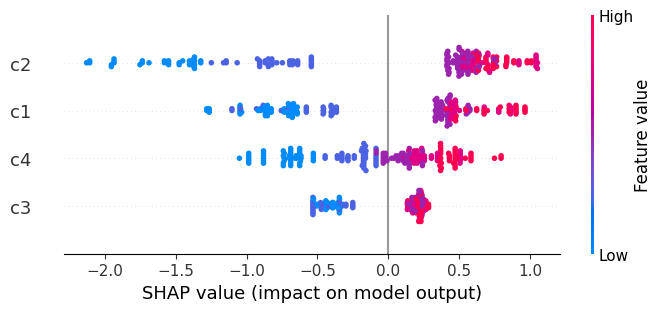

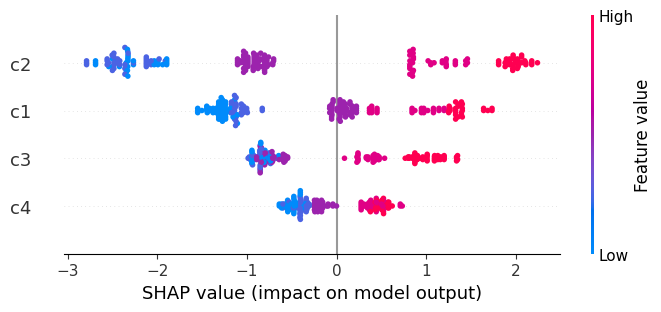

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
# shape: (n_samples, n_features, n_classes)

shap.plots.beeswarm(shap_values[:, :, 0], show=True)  # class 0
shap.plots.beeswarm(shap_values[:, :, 1], show=True)  # class 1
shap.plots.beeswarm(shap_values[:, :, 2], show=True)  # class 2

## SHAP Interpretation

**Class 0 (low):** SHAP values are near zero for all criteria. The model does not
actively predict class 0, it falls there by default when evidence for classes 1 and 2
is absent. This is expected given class 0 is the merged boundary group.

**Class 1 (medium):** c2 is the dominant criterion — high values (red) push strongly
toward class 1, low values (blue) push away. c1 follows the same pattern but weaker.
c3 and c4 have minimal spread, confirming low importance from the gain plot.

**Class 2 (high):** c2 again dominates, but now high values push even more strongly
positive (up to +2). c1 also contributes significantly. c3 shows some effect,
c4 remains weak. The clear blue/red separation confirms all criteria are monotone,
low feature value always pushes negative, high always pushes positive.

**Summary:** As we could previously seen on the feature importance plot, also Shap shows that c2 is the most influential criterion, approximately 2x more than c1. c3 and c4 have limited effect. 

## Partial Dependence Plots (PDP)

PDP shows the average predicted probability for each class as a single criterion
varies across its range, with all other criteria held at their mean.
Flat regions indicate indifference — the criterion has no effect in that range.
Steep regions indicate preference thresholds where small changes matter most.

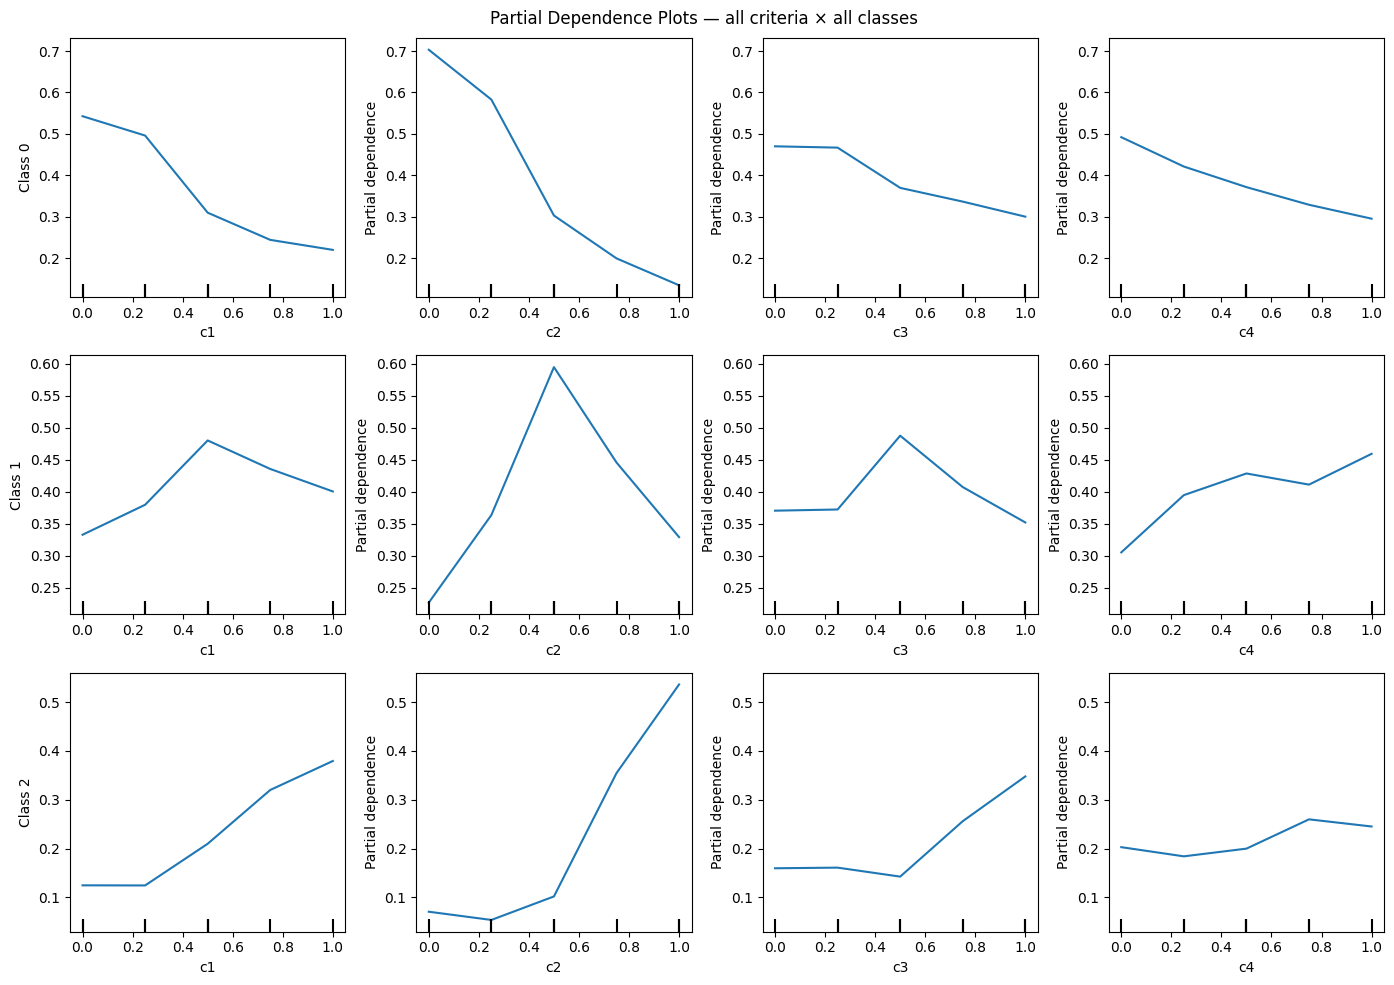

In [17]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for cls in range(3):
    PartialDependenceDisplay.from_estimator(
        model, X_train,
        features=[0, 1, 2, 3],
        target=cls,
        ax=axes[cls],
    )
    axes[cls][0].set_ylabel(f"Class {cls}")

plt.suptitle("Partial Dependence Plots — all criteria × all classes")
plt.tight_layout()
plt.show()

## PDP Interpretation

Common behaviour across class 1 PDP plots: all criteria show a non-monotonic shape —
probability rises then falls as the criterion increases. This is expected: monotone_constraints
enforce that higher values push toward higher classes overall, not that each individual
class probability must be monotone. The middle class naturally peaks at intermediate values.

Criterion-wise PDP analysis:

c1: non-monotonic for class 1 (peaks ~0.4 then slightly drops), monotone for classes 0 and 2.
Higher c1 → less class 0, more class 2. 

c2: most influential criterion. Non-monotonic for class 1 — peaks sharply at ~0.5 then drops.
Low c2 → class 0, medium c2 → class 1, high c2 → class 2.

c3: similar non-monotonic pattern for class 1, peaks around 0.5–0.6 then flattens.
Weak but present effect on class 2. Mostly flat for class 0 until ~0.4.

c4: weakest criterion overall. Near-flat curves across all classes, slight non-monotonicity
in class 1. Confirms lowest importance from gain plot.